<a href="https://colab.research.google.com/github/GaboGolCs/PainPredict-Neuro/blob/feat%2Fg3-actividad2-espectral/notebooks/Actividad_2_%E2%80%93_An%C3%A1lisis_Espectral_por_Condici%C3%B3n_(Dolor_NRS_2%2C_4%2C_6%2C_8).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad 2: Análisis Espectral por Condición (NRS 2, 4, 6, 8)


Este notebook procesa las características espectrales de señales EEG, aplicando transformaciones logarítmicas para visualizar la desincronización de la banda Alpha Parietal y la evolución de la banda Theta según la escala numérica del dolor (NRS).

## Bloque 1 y 2: Importación, Carga de Datos y Transformación (Juan)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# Configuración del estilo visual para gráficos
sns.set_theme(style="whitegrid")

# Montaje de la unidad de Google Drive
drive.mount('/content/drive')

# Definición de la ruta del dataset en la unidad compartida
ruta_csv = '/content/drive/Shareddrives/DATA_GPI/Nuestros Datasets/dataset_features_eeg.csv'

# Carga de datos
df = pd.read_csv(ruta_csv)

# Verificación de la estructura inicial de los datos
print("Carga de datos original completada.")
display(df.head())

Mounted at /content/drive
Carga de datos original completada.


,subject_id,trial_num,nrs_score,theta_frontal,theta_central,theta_parietal,alpha_frontal,alpha_central,alpha_parietal,beta_frontal,beta_central,beta_parietal
0,sub-001,1,33,7.369909e-13,1.007540e-12,1.976498e-12,3.471938e-13,9.253832e-13,1.710378e-12,2.044873e-13,1.931701e-13,5.279739e-13
1,sub-001,2,34,9.778087e-13,1.114274e-12,3.289422e-12,4.195572e-13,1.147543e-12,2.875312e-12,3.576079e-13,3.789653e-13,4.762207e-13
2,sub-001,3,34,1.780755e-12,2.189734e-12,3.366693e-12,8.567443e-13,1.633348e-12,2.542984e-12,2.674932e-13,2.582144e-13,6.238050e-13
3,sub-001,4,35,1.769780e-12,2.784121e-12,7.606693e-12,1.038100e-12,1.564711e-12,3.714738e-12,3.138034e-13,2.367524e-13,3.781213e-13
4,sub-001,5,34,1.617100e-12,2.167452e-12,4.948541e-12,2.502550e-13,3.032959e-13,1.217035e-12,4.062235e-13,2.470218e-13,6.838558e-13


In [ ]:
# Definición de las bandas de EEG a procesar
bandas_eeg = [
    'theta_frontal',
    'alpha_frontal',
    'beta_frontal',
    'theta_central',
    'alpha_central',
    'beta_central',
    'theta_parietal',
    'alpha_parietal',
    'beta_parietal'
]

# Creación de copia del DataFrame y aplicación de transformación logarítmica (base 10)
df_log = df.copy()
for banda in bandas_eeg:
    df_log[banda] = np.log10(df_log[banda])

# Verificación de los datos transformados a escala logarítmica
print("Transformación logarítmica completada.")
display(df_log[['subject_id', 'nrs_score'] + bandas_eeg].head())

Transformación logarítmica completada.


,subject_id,nrs_score,theta_frontal,alpha_frontal,beta_frontal,theta_central,alpha_central,beta_central,theta_parietal,alpha_parietal,beta_parietal
0,sub-001,33,-12.132538,-12.459428,-12.689334,-11.996738,-12.033678,-12.714060,-11.704104,-11.766908,-12.277388
1,sub-001,34,-12.009746,-12.377209,-12.446593,-11.953008,-11.940231,-12.421401,-11.482880,-11.541315,-12.322192
2,sub-001,34,-11.749396,-12.067149,-12.572687,-11.659609,-11.786921,-12.588020,-11.472797,-11.594656,-12.204951
3,sub-001,35,-11.752081,-11.983761,-12.503342,-11.555312,-11.805566,-12.625706,-11.118804,-11.430072,-12.422369
4,sub-001,34,-11.791263,-12.601617,-12.391235,-11.664050,-12.518133,-12.607265,-11.305523,-11.914697,-12.165035


## Bloque 3: Distribución de la Banda Alpha Parietal (Ivonne)

Escala NRS mapeada exitosamente a 2, 4, 6 y 8.


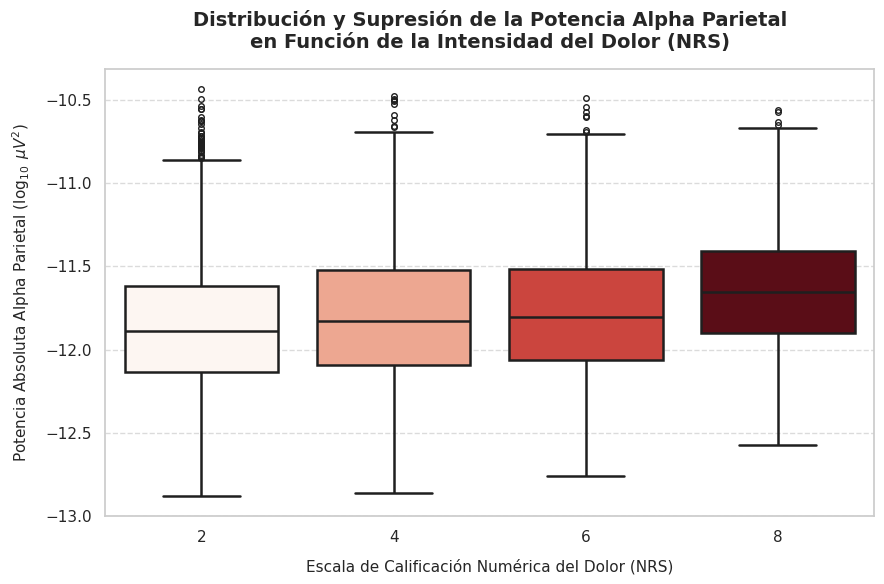

In [ ]:
# Debe usar df_log, x='nrs_score', y='alpha_parietal'

# 1. Configuración solicitada para el diseño de los gráficos
sns.set_theme(style="whitegrid")

# 2. Mapeo de bloques experimentales a escala NRS real (Solo transforma si detecta los códigos originales)
mapeo_nrs = {32: 2, 33: 4, 34: 6, 35: 8}

# Verificamos si el valor 32 existe en la columna antes de mapear (Para evitar error al compilar por 2da vez)
if df_log['nrs_score'].isin([32]).any():
    df_log['nrs_score'] = df_log['nrs_score'].map(mapeo_nrs)
    print("Escala NRS mapeada exitosamente a 2, 4, 6 y 8.")
else:
    print("La columna 'nrs_score' ya se encuentra en la escala correcta (2-8).")


# 3. Inicialización del lienzo del gráfico
plt.figure(figsize=(9, 6))

# Construcción del Boxplot corregido (sin Warnings de 'palette' o 'hue')
sns.boxplot(
    x='nrs_score',
    y='alpha_parietal',
    hue='nrs_score',
    data=df_log,
    palette='Reds',
    linewidth=1.8,
    fliersize=4,
    legend=False
)

# 4. Formalización de Títulos y Etiquetas
plt.title('Distribución y Supresión de la Potencia Alpha Parietal\nen Función de la Intensidad del Dolor (NRS)',
          fontsize=14, fontweight='bold', pad=15)

plt.xlabel('Escala de Calificación Numérica del Dolor (NRS)', fontsize=11, labelpad=10)
plt.ylabel(r'Potencia Absoluta Alpha Parietal ($\log_{10}$ $\mu V^2$)', fontsize=11, labelpad=10) #El prefijo 'r' soluciona el SyntaxWarning del formato LaTeX (\mu y \log)

# Ajuste de la cuadrícula horizontal sutil
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 5. Renderizado limpio
plt.tight_layout()
plt.show()

## Bloque 4: Tendencia Global de la Banda Theta (Ignacio)

Iniciando Bloque 4: Generando Pointplot de la Banda Theta...


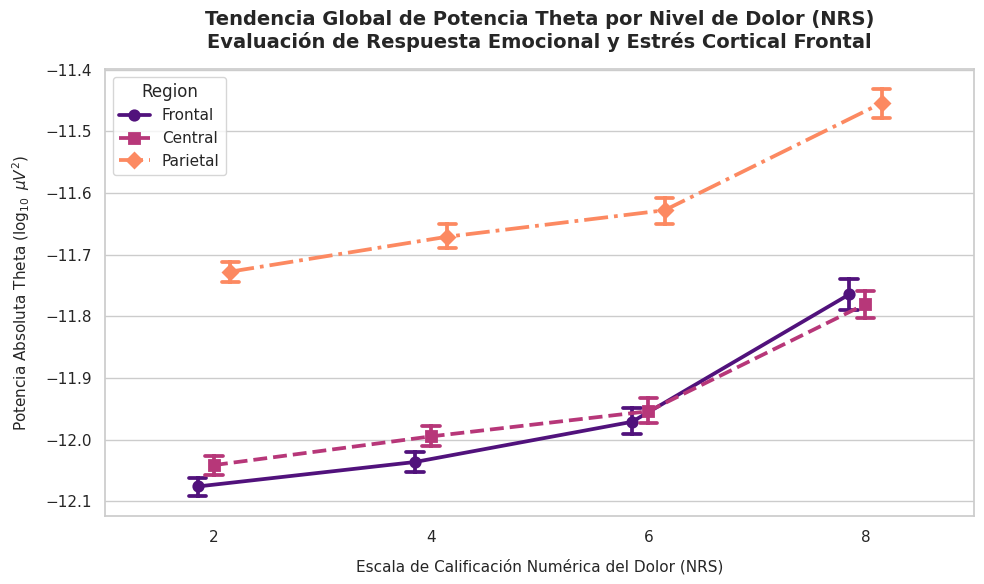

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

print("Iniciando Bloque 4: Generando Pointplot de la Banda Theta...")

# 1. PREPARACIÓN DE DATOS (Transformación Wide a Long)
# Definimos las columnas específicas de la banda Theta en sus 3 regiones
columnas_theta = ['theta_frontal', 'theta_central', 'theta_parietal']

# Extraemos una copia temporal de la información requerida desde el DataFrame maestro 'df_log'
df_theta = df_log[['nrs_score'] + columnas_theta].copy()

# Transformamos la estructura de columnas de regiones a filas para optimizar el mapeo del hue de Seaborn
df_theta_melted = df_theta.melt(
    id_vars=['nrs_score'],
    value_vars=columnas_theta,
    var_name='Region',
    value_name='Potencia_Log10'
)

# Limpieza y formateo de etiquetas para la leyenda del gráfico final
df_theta_melted['Region'] = df_theta_melted['Region'].str.replace('theta_', '').str.capitalize()


# 2. INICIALIZACIÓN DEL LIENZO Y ESTILO
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")


# 3. CONSTRUCCIÓN DEL POINTPLOT (Tendencias globales e intervalos de confianza)
# El parámetro dodge=True evita el solapamiento visual de los intervalos de confianza
sns.pointplot(
    data=df_theta_melted,
    x='nrs_score',
    y='Potencia_Log10',
    hue='Region',
    palette='magma',          # Paleta térmica secuencial idónea para neurociencias
    markers=['o', 's', 'D'],  # Marcadores distintos para cada región (Círculo, Cuadrado, Diamante)
    linestyles=['-', '--', '-.'], # Estilos de línea diferenciados para máxima legibilidad
    dodge=0.15,               # Separación sutil lateral para evitar choques visuales
    capsize=0.08,             # Añade barras transversales a los intervalos de confianza clínicos
    errorbar=('ci', 95)       # Calcula y dibuja los intervalos de confianza estrictos al 95%
)


# 4. FORMALIZACIÓN DE TÍTULOS Y ETIQUETAS CLÍNICAS
plt.title('Tendencia Global de Potencia Theta por Nivel de Dolor (NRS)\nEvaluación de Respuesta Emocional y Estrés Cortical Frontal',
          fontsize=14, fontweight='bold', pad=15)

plt.xlabel('Escala de Calificación Numérica del Dolor (NRS)', fontsize=11, labelpad=10)
plt.ylabel(r'Potencia Absoluta Theta ($\log_{10}$ $\mu V^2$)', fontsize=11, labelpad=10)

plt.tight_layout()
plt.show()